## Reproducible "10 random runs" pipeline (CV1/CV2/CV3) — H2018 GIV, K562 (2026-04-17)

This self-contained section reproduces the random 10-runs experiment from the sections above using the
**optimal settings identified in this notebook** so we can re-run it in the new `deepslp` environment.

**Optimal settings chosen (from the latest CV1/CV2/CV3 blocks above):**
- Architecture: 3-hidden-layer MLP with BatchNorm + Dropout(0.3), hidden sizes = `[128, 64, 32]`, output size = 1.
- Loss: `FocalLoss(alpha=0.75, gamma=1.5)` on BCE-with-logits.
- Optimizer: Adam, `lr=1e-2`, `ReduceLROnPlateau(factor=0.1, patience=5)` on val loss.
- Training: `batch_size=64`, `num_epochs=50`, early-stopping `patience=10` on best **val AUPR**.
- Data splits: CV1 random (test=0.1, val=0.1); CV2 query holdout (test=0.1, val=0.1); CV3 double holdout (test=0.21, val=0.21 → ≈80/10/10 of pairs).
- Seeds: `rand_seed = i + 1842` for `i = 1..10` (matches the CV1/CV2/CV3 blocks above).
- Top-K for Precision/Recall@K: `K=100`.

**Target:** K562 (`label_col='K_SL_n3'`). Switch to Jurkat by setting `CELL_LINE = 'J'` in the config cell.

**Input:** `DeepSLP/data/input/external/H2018/GIV_H2018/H2018_map3_24Q4_GIV_{0..3}.tsv`

**Output:** `DeepSLP/outputs/H2018_reproduce_04172026/{CV1,CV2,CV3}/` — per-run models, scalers, prediction tables, ROC/PR plots, and a per-CV `*_performance_stats_10folds.tsv`. A final aggregate table `summary_mean_std.tsv` is written at the end for downstream bar plots.


In [1]:
# --- Imports (standalone: safe to re-run the section below from scratch in `deepslp`) ---
import os, time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             auc, accuracy_score, average_precision_score, f1_score)

print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())


torch: 2.5.1+cu121 | cuda available: True


In [2]:
# --- Model + loss (focal-loss, single-logit binary classifier) ---
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(hidden_size3, output_size)

    def forward(self, x):
        x = self.dropout1(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(torch.relu(self.bn2(self.fc2(x))))
        x = self.dropout3(torch.relu(self.bn3(self.fc3(x))))
        x = self.fc4(x).squeeze(-1)
        return x


class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


In [3]:
# --- Small helpers (logging, metrics, plots) ---
def create_directory(dir_path):
    os.makedirs(dir_path, exist_ok=True)
    print(f"Directory '{dir_path}' is ready.")

def log_message(message):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{ts}] {message}")

def recall_at_k(y_true, y_pred, K):
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    total_relevant = np.sum(y_true)
    return relevant_at_k / total_relevant if total_relevant > 0 else 0.0

def precision_at_k(y_true, y_pred, K):
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    return relevant_at_k / K if K > 0 else 0.0

def plot_ROC_PR(all_labels, all_probs, plt_direc='./ROC_PR_curves.pdf', K=100):
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    average_precision = average_precision_score(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)
    print(f'ROC AUC: {roc_auc:.4f} | PRC AUC: {pr_auc:.4f} | AP: {average_precision:.4f}')

    recall_k = recall_at_k(all_labels, all_probs, K)
    precision_k = precision_at_k(all_labels, all_probs, K)
    print(f"Recall@{K}: {recall_k:.4f} | Precision@{K}: {precision_k:.4f}")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'PR (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR Curve'); plt.legend()
    plt.tight_layout()
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=200)
    plt.close()
    return [roc_auc, pr_auc, average_precision, recall_k, precision_k]

def plot_losses(train_vals, val_vals, train_label="Training Loss", val_label="Validation Loss", plt_direc=None):
    epochs = list(range(1, len(train_vals) + 1))
    plt.figure(figsize=(9, 5))
    plt.plot(epochs, train_vals, label=train_label, marker="o")
    plt.plot(epochs, val_vals, label=val_label, marker="o")
    plt.xlabel("Epoch"); plt.ylabel("Value"); plt.legend(); plt.grid(True)
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=200)
    plt.close()

def evaluate_metrics(model, data_loader, device):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device); labels = labels.to(device).float()
            logits = model(inputs).squeeze(-1)
            probs = torch.sigmoid(logits)
            all_labels.append(labels.cpu()); all_probs.append(probs.cpu())
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()
    aupr = average_precision_score(all_labels, all_probs)
    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auroc = float('nan')
    return aupr, auroc


In [4]:
# --- Split function: CV1 random / CV2 query-holdout / CV3 double-holdout ---
def split_train_val_test_cv(df, label_col, non_feature_cols,
                            query_col='gene1', lib_col='gene2',
                            test_ratio=0.2, val_ratio=0.1, rand_seed=42, cv=1, k=1):
    features = df.drop(columns=non_feature_cols)
    features.dropna(axis=0, how='any', inplace=True)

    if cv == 1:
        df_sub = df.loc[features.index]
        train_df, temp_df = train_test_split(
            df_sub, test_size=(test_ratio + val_ratio),
            stratify=df_sub[label_col], random_state=rand_seed)
        val_size = val_ratio / (val_ratio + test_ratio)
        val_df, test_df = train_test_split(
            temp_df, test_size=(1 - val_size),
            stratify=temp_df[label_col], random_state=rand_seed)
        print(f"Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")
        X_train = train_df.drop(columns=non_feature_cols); y_train = train_df[label_col]
        X_val   = val_df.drop(columns=non_feature_cols);   y_val   = val_df[label_col]
        X_test  = test_df.drop(columns=non_feature_cols);  y_test  = test_df[label_col]

    elif cv == 2:
        df_sub = df.loc[features.index, [query_col]]
        labels = df.loc[features.index, label_col]
        query_genes = df_sub[query_col].unique()
        print(len(query_genes), "unique queries")
        test_len = int(len(query_genes) * test_ratio)
        val_len  = int(len(query_genes) * val_ratio)
        np.random.seed(rand_seed)
        test_query  = np.random.choice(query_genes, size=test_len, replace=False)
        train_query = list(set(query_genes) - set(test_query))
        val_query   = np.random.choice(train_query, size=val_len, replace=False)
        train_query = list(set(train_query) - set(val_query))
        print(len(train_query), "train /", len(val_query), "val /", len(test_query), "test queries")

        train_idx = df_sub[df_sub[query_col].isin(train_query)].index
        val_idx   = df_sub[df_sub[query_col].isin(val_query)].index
        test_idx  = df_sub[df_sub[query_col].isin(test_query)].index
        X_train = features.loc[train_idx]; y_train = labels.loc[train_idx]
        X_val   = features.loc[val_idx];   y_val   = labels.loc[val_idx]
        X_test  = features.loc[test_idx];  y_test  = labels.loc[test_idx]
        print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

    elif cv == 3:
        df_sub = df.loc[features.index, [query_col, lib_col, label_col]]
        labels = df_sub[label_col]
        SL_potential_score = df.loc[features.index].groupby(query_col).agg({label_col: "sum"}).reset_index()
        SL_potential_score.columns = ["gene", "num_SL_partner"]
        training_percent = 1 - test_ratio - val_ratio
        val_percent = val_ratio
        num_samples = SL_potential_score.shape[0]
        all_idx = list(range(num_samples))
        np.random.seed(rand_seed)
        np.random.shuffle(all_idx)

        SL_tr  = SL_potential_score.iloc[all_idx[:int(num_samples * training_percent)]]
        SL_va  = SL_potential_score.iloc[all_idx[int(num_samples * training_percent):int(num_samples * (training_percent + val_percent))]]
        SL_te  = SL_potential_score.iloc[all_idx[int(num_samples * (training_percent + val_percent)):]]
        training_genes = SL_tr["gene"].values
        val_genes      = SL_va["gene"].values
        test_genes     = SL_te["gene"].values

        SL_pair_train = df_sub[(df_sub[query_col].isin(training_genes)) & (df_sub[lib_col].isin(training_genes))]
        SL_pair_val   = df_sub[(df_sub[query_col].isin(val_genes))      & (df_sub[lib_col].isin(val_genes))]
        SL_pair_test  = df_sub[(df_sub[query_col].isin(test_genes))     & (df_sub[lib_col].isin(test_genes))]

        X_train = features.loc[SL_pair_train.index]; y_train = labels.loc[SL_pair_train.index]
        X_val   = features.loc[SL_pair_val.index];   y_val   = labels.loc[SL_pair_val.index]
        X_test  = features.loc[SL_pair_test.index];  y_test  = labels.loc[SL_pair_test.index]
        print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
        print("Excluded pairs:", features.shape[0] - X_train.shape[0] - X_val.shape[0] - X_test.shape[0])
    else:
        raise ValueError("cv must be 1, 2, or 3")

    return {'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test}


In [5]:
# --- Train / validate / test with FocalLoss and early stopping on best val AUPR ---
def train_validate_test_NN(splits, df, non_feature_cols,
                           output_dir, plt_name, table_name,
                           batch_size=64, num_epochs=50, learning_rate=1e-2,
                           patience=10, decay_factor=0.1,
                           bool_save_model=True, model_name='model.pth',
                           scaler_direc=None, bool_plot_loss=True,
                           hidden_size1=128, hidden_size2=64, hidden_size3=32, topk=100,
                           focal_alpha=0.75, focal_gamma=1.5):
    device = ("cuda" if torch.cuda.is_available()
              else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using {device} device")

    X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']
    y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
    test_idx = y_test.index

    # Standardize
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)
    if scaler_direc is not None:
        joblib.dump(scaler, os.path.join(output_dir, scaler_direc))

    # Tensors
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32)
    X_va_t = torch.tensor(X_val_s,   dtype=torch.float32)
    X_te_t = torch.tensor(X_test_s,  dtype=torch.float32)
    y_tr_t = torch.tensor(y_train.values, dtype=torch.long)
    y_va_t = torch.tensor(y_val.values,   dtype=torch.long)
    y_te_t = torch.tensor(y_test.values,  dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=batch_size, shuffle=False)

    input_size = X_train_s.shape[1]
    model = NeuralNetwork(input_size, hidden_size1, hidden_size2, hidden_size3, output_size=1).to(device)
    criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=decay_factor, patience=5, verbose=False)

    best_aupr = 0.0
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses, train_auprs, val_auprs = [], [], [], []

    log_message("Training started")
    t0 = time.time()
    for epoch in range(num_epochs):
        model.train()
        running = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, labels)
            loss.backward(); optimizer.step()
            running += loss.item() * inputs.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float()
                outputs = model(inputs).squeeze(-1)
                vl += criterion(outputs, labels).item() * inputs.size(0)
        val_loss = vl / len(val_loader.dataset)
        scheduler.step(val_loss)

        train_aupr, train_auroc = evaluate_metrics(model, train_loader, device)
        val_aupr, val_auroc     = evaluate_metrics(model, val_loader, device)
        train_losses.append(train_loss); val_losses.append(val_loss)
        train_auprs.append(train_aupr);  val_auprs.append(val_aupr)
        print(f"Ep {epoch+1}/{num_epochs}: TrL={train_loss:.4f} VaL={val_loss:.4f} | TrAUPR={train_aupr:.4f} VaAUPR={val_aupr:.4f}")

        if val_aupr > best_aupr:
            best_aupr = val_aupr; epochs_no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping."); break

    log_message(f"Total training time: {time.time()-t0:.2f}s")
    if bool_plot_loss:
        plot_losses(train_losses, val_losses,
                    plt_direc=os.path.join(output_dir, plt_name.replace('.', '_train_val_loss.')))
        plot_losses(train_auprs, val_auprs, train_label="Training AUPR", val_label="Validation AUPR",
                    plt_direc=os.path.join(output_dir, plt_name.replace('.', '_train_val_aupr.')))

    if best_state is not None:
        model.load_state_dict(best_state)
    if bool_save_model:
        torch.save(model, os.path.join(output_dir, model_name))

    # Test
    model.eval()
    all_labels, all_scores = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            outputs = model(inputs).squeeze(-1)
            probs = torch.sigmoid(outputs)
            all_scores.append(probs.cpu()); all_labels.append(labels.cpu())
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()

    perf = plot_ROC_PR(all_labels, all_scores,
                       plt_direc=os.path.join(output_dir, plt_name), K=topk)
    df_test = df.loc[test_idx, non_feature_cols].copy()
    df_test['predict_proba'] = all_scores
    df_test.to_csv(os.path.join(output_dir, table_name), sep='\t')
    return model, df_test, perf


def optim_NN_pipeline(df_score, label_col, non_feature_cols,
                      test_ratio=0.1, val_ratio=0.1, rand_seed=42,
                      output_dir='./', plt_name='roc_pr.pdf', table_name='pred.tsv',
                      batch_size=64, num_epochs=50, bool_save_model=True, model_name='model.pth',
                      scaler_direc=None, bool_plot_loss=True,
                      hidden_size1=128, hidden_size2=64, hidden_size3=32,
                      learning_rate=1e-2, patience=10, decay_factor=0.1,
                      cv=1, query_col='gene1', lib_col='gene2', topk=100,
                      focal_alpha=0.75, focal_gamma=1.5):
    create_directory(output_dir)
    df = df_score[df_score[query_col] != df_score[lib_col]]
    if cv not in [1, 2, 3]:
        raise ValueError("cv must be 1, 2, or 3")
    print(f"Data split: CV{cv} | seed={rand_seed}")
    splits = split_train_val_test_cv(df, label_col=label_col, query_col=query_col, lib_col=lib_col,
                                     non_feature_cols=non_feature_cols,
                                     test_ratio=test_ratio, val_ratio=val_ratio,
                                     rand_seed=rand_seed, cv=cv)
    return train_validate_test_NN(
        splits, df=df, non_feature_cols=non_feature_cols,
        output_dir=output_dir, plt_name=plt_name, table_name=table_name,
        batch_size=batch_size, num_epochs=num_epochs, learning_rate=learning_rate,
        patience=patience, decay_factor=decay_factor,
        bool_save_model=bool_save_model, model_name=model_name,
        scaler_direc=scaler_direc, bool_plot_loss=bool_plot_loss,
        hidden_size1=hidden_size1, hidden_size2=hidden_size2, hidden_size3=hidden_size3,
        topk=topk, focal_alpha=focal_alpha, focal_gamma=focal_gamma)


In [6]:
# --- Load H2018 GIV data from the new location in `deepslp` workspace ---
H2018_GIV_DIR = "/home/b-xiangzhang/DeepSLP/data/input/external/H2018/GIV_H2018/"

def _concat_giv_files(input_dir, iter_num=4, tail='.tsv', sep_='\t'):
    # Concatenate H2018_map3_24Q4_GIV_{0..iter_num-1}.tsv in order
    dfs = []
    files = os.listdir(input_dir)
    for i in range(iter_num):
        suffix = f"_{i}{tail}"
        for f in files:
            if f.endswith(suffix):
                print("Loading", f)
                dfs.append(pd.read_csv(os.path.join(input_dir, f), sep=sep_, index_col=None))
    out = pd.concat(dfs).reset_index(drop=True)
    return out

df_SL_H2018 = _concat_giv_files(H2018_GIV_DIR, iter_num=4)
print("df_SL_H2018 shape:", df_SL_H2018.shape)

# Derive binary SL labels: GI < -3 is stringent SL
df_SL_H2018['K_SL_n3'] = (df_SL_H2018['K562 Replicate Average GI score']   < -3).astype(int)
df_SL_H2018['J_SL_n3'] = (df_SL_H2018['Jurkat Replicate Average GI score'] < -3).astype(int)

# Drop rows with missing scores per cell line (only done when that cell line is used)
df_SL_H2018_K_noNAscore = df_SL_H2018[df_SL_H2018['K562 Replicate Average GI score'].notnull()].copy()
df_SL_H2018_J_noNAscore = df_SL_H2018[df_SL_H2018['Jurkat Replicate Average GI score'].notnull()].copy()

# Non-feature columns (match the original notebook convention):
# original metadata cols + both derived labels
H2018_meta_cols = ['gene1', 'gene2',
                   'K562 Replicate Average GI score',
                   'Jurkat Replicate Average GI score']
H2018_non_feature_cols = H2018_meta_cols + ['K_SL_n3', 'J_SL_n3']

print("K562 pairs:", df_SL_H2018_K_noNAscore.shape,
      "| pos rate:", df_SL_H2018_K_noNAscore['K_SL_n3'].mean())
print("Jurkat pairs:", df_SL_H2018_J_noNAscore.shape,
      "| pos rate:", df_SL_H2018_J_noNAscore['J_SL_n3'].mean())
print("#feature cols:", df_SL_H2018_K_noNAscore.shape[1] - len(H2018_non_feature_cols))


Loading H2018_map3_24Q4_GIV_0.tsv
Loading H2018_map3_24Q4_GIV_1.tsv
Loading H2018_map3_24Q4_GIV_2.tsv
Loading H2018_map3_24Q4_GIV_3.tsv
df_SL_H2018 shape: (104901, 260)
K562 pairs: (100576, 262) | pos rate: 0.01668390073178492
Jurkat pairs: (75466, 262) | pos rate: 0.006015954204542443
#feature cols: 256


In [7]:
# --- Reproducible run config ---
# Switch CELL_LINE to 'J' to train/evaluate on Jurkat with the exact same pipeline.
CELL_LINE = 'K'   # 'K' for K562, 'J' for Jurkat

if CELL_LINE == 'K':
    REPRO_DF    = df_SL_H2018_K_noNAscore
    REPRO_LABEL = 'K_SL_n3'
elif CELL_LINE == 'J':
    REPRO_DF    = df_SL_H2018_J_noNAscore
    REPRO_LABEL = 'J_SL_n3'
else:
    raise ValueError("CELL_LINE must be 'K' or 'J'")

REPRO_ROOT   = f"/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/{CELL_LINE}562/" if CELL_LINE == 'K' else f"/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/Jurkat/"
N_RUNS       = 10
TOPK         = 100
SEED_BASE    = 1842    # rand_seed = i + SEED_BASE for i in 1..N_RUNS (matches final CV1/CV2/CV3 blocks above)

# Optimal hyperparameters (from the latest CV1/CV2/CV3 blocks)
HP = dict(
    hidden_size1=128, hidden_size2=64, hidden_size3=32,
    batch_size=64, num_epochs=50,
    learning_rate=1e-2, patience=10, decay_factor=0.1,
    focal_alpha=0.75, focal_gamma=1.5,
)

# Per-CV split ratios
CV_SPLIT = {
    1: dict(test_ratio=0.10, val_ratio=0.10),  # random holdout on pairs
    2: dict(test_ratio=0.10, val_ratio=0.10),  # query-gene holdout
    3: dict(test_ratio=0.21, val_ratio=0.21),  # double holdout -> ~80/10/10 kept pairs
}

create_directory(REPRO_ROOT)
print("Cell line:", CELL_LINE, "| label:", REPRO_LABEL, "| output root:", REPRO_ROOT)


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/' is ready.
Cell line: K | label: K_SL_n3 | output root: /home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/


In [8]:
# --- Wrapper: run 10 random repeats for one CV scenario and collect performance ---
def run_cv_repeats(cv, df_score, label_col, non_feature_cols,
                   output_root, n_runs=10, seed_base=1842,
                   topk=100, hp=None, cv_split=None,
                   query_col='gene1', lib_col='gene2', prefix_tag=None):
    assert cv in (1, 2, 3)
    hp = hp or HP
    cv_split = cv_split or CV_SPLIT
    ratios = cv_split[cv]

    tag = prefix_tag or f"CV{cv}"
    cv_dir = os.path.join(output_root, f"CV{cv}/")
    create_directory(cv_dir)

    prefix = f"{tag}_GIV_NN_h128_64_32_LR1e2_50e_p{hp['patience']}_d01_focal"
    perf_rows = []
    for i in range(1, n_runs + 1):
        seed = i + seed_base
        run_tag = str(i)
        print(f"\n===== {tag} run {i}/{n_runs} (seed={seed}) =====")
        model, df_test, perf = optim_NN_pipeline(
            df_score=df_score, label_col=label_col, non_feature_cols=non_feature_cols,
            test_ratio=ratios['test_ratio'], val_ratio=ratios['val_ratio'],
            rand_seed=seed,
            output_dir=cv_dir,
            plt_name=prefix + f"_ROC_PR_curves_{run_tag}.pdf",
            table_name=prefix + f"_preds_{run_tag}.tsv",
            batch_size=hp['batch_size'], num_epochs=hp['num_epochs'],
            learning_rate=hp['learning_rate'], patience=hp['patience'],
            decay_factor=hp['decay_factor'],
            hidden_size1=hp['hidden_size1'], hidden_size2=hp['hidden_size2'], hidden_size3=hp['hidden_size3'],
            bool_save_model=True, model_name=prefix + f"_{run_tag}.pth",
            scaler_direc=f"CV{cv}_seed{seed}.joblib", bool_plot_loss=True,
            cv=cv, query_col=query_col, lib_col=lib_col, topk=topk,
            focal_alpha=hp['focal_alpha'], focal_gamma=hp['focal_gamma'])
        perf_rows.append([seed] + list(perf))

    df_perf = pd.DataFrame(perf_rows, columns=['seed', 'AUROC', 'AUPR', 'AP',
                                               f'Recall@{topk}', f'Precision@{topk}'])
    df_perf.to_csv(os.path.join(cv_dir, prefix + f"_performance_stats_{n_runs}runs.tsv"),
                   sep='\t', index=False)
    print("\n--- Mean across runs ---"); print(df_perf.drop(columns='seed').mean(axis=0))
    print("\n--- Std across runs ---");  print(df_perf.drop(columns='seed').std(axis=0))
    return df_perf


In [13]:
# --- Run CV1 (random pair holdout) ---
df_perf_cv1 = run_cv_repeats(
    cv=1, df_score=REPRO_DF, label_col=REPRO_LABEL, non_feature_cols=H2018_non_feature_cols,
    output_root=REPRO_ROOT, n_runs=N_RUNS, seed_base=SEED_BASE, topk=TOPK)
df_perf_cv1


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/CV1/' is ready.

===== CV1 run 1/10 (seed=1843) =====
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/CV1/' is ready.
Data split: CV1 | seed=1843
Train=75516, Val=9439, Test=9440
Using cuda device
[2026-04-20 14:58:42] Training started
Ep 1/50: TrL=0.0244 VaL=0.0213 | TrAUPR=0.0601 VaAUPR=0.0721
Ep 2/50: TrL=0.0221 VaL=0.0212 | TrAUPR=0.0918 VaAUPR=0.0991
Ep 3/50: TrL=0.0215 VaL=0.0209 | TrAUPR=0.0839 VaAUPR=0.1093
Ep 4/50: TrL=0.0211 VaL=0.0201 | TrAUPR=0.0987 VaAUPR=0.1335
Ep 5/50: TrL=0.0208 VaL=0.0193 | TrAUPR=0.1187 VaAUPR=0.1341
Ep 6/50: TrL=0.0206 VaL=0.0188 | TrAUPR=0.1302 VaAUPR=0.1588
Ep 7/50: TrL=0.0203 VaL=0.0196 | TrAUPR=0.1349 VaAUPR=0.1331
Ep 8/50: TrL=0.0198 VaL=0.0187 | TrAUPR=0.1569 VaAUPR=0.1344
Ep 9/50: TrL=0.0196 VaL=0.0183 | TrAUPR=0.1635 VaAUPR=0.1652
Ep 10/50: TrL=0.0198 VaL=0.0190 | TrAUPR=0.1578 VaAUPR=0.1599
Ep 11/50: TrL=0.0195 VaL=0.0183 | TrAUPR=0.1698 V

,seed,AUROC,AUPR,AP,Recall@100,Precision@100
0,1843,0.860668,0.149027,0.151590,0.184932,0.27
1,1844,0.877599,0.224802,0.161460,0.184932,0.27
2,1845,0.849768,0.129522,0.132555,0.143836,0.21
3,1846,0.849493,0.168856,0.170652,0.171233,0.25
4,1847,0.827227,0.104424,0.108863,0.130137,0.19
5,1848,0.866296,0.131793,0.134642,0.171233,0.25
6,1849,0.840838,0.110535,0.113915,0.136986,0.20
7,1850,0.872548,0.159106,0.162350,0.178082,0.26
8,1851,0.886545,0.200876,0.203231,0.191781,0.28
9,1852,0.884041,0.173073,0.177890,0.184932,0.27


In [14]:
df_perf_cv1.mean()

seed             1847.500000
AUROC               0.861502
AUPR                0.155201
AP                  0.151715
Recall@100          0.167808
Precision@100       0.245000
dtype: float64

In [9]:
# --- Run CV2 (query-gene holdout; query_col='gene1') ---
# Switch to 1897 as the seed to avoid issue caused by batch size
df_perf_cv2 = run_cv_repeats(
    cv=2, df_score=REPRO_DF, label_col=REPRO_LABEL, non_feature_cols=H2018_non_feature_cols,
    output_root=REPRO_ROOT, n_runs=N_RUNS, seed_base=1897, topk=TOPK,
    query_col='gene1', lib_col='gene2')
df_perf_cv2


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/CV2/' is ready.

===== CV2 run 1/10 (seed=1898) =====
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/CV2/' is ready.
Data split: CV2 | seed=1898
434 unique queries
348 train / 43 val / 43 test queries
Shapes: (73814, 256) (9855, 256) (10726, 256)
Using cuda device
[2026-04-20 14:28:02] Training started
Ep 1/50: TrL=0.0270 VaL=0.0171 | TrAUPR=0.0642 VaAUPR=0.0401
Ep 2/50: TrL=0.0233 VaL=0.0157 | TrAUPR=0.0859 VaAUPR=0.0739
Ep 3/50: TrL=0.0227 VaL=0.0154 | TrAUPR=0.0990 VaAUPR=0.0753
Ep 4/50: TrL=0.0224 VaL=0.0151 | TrAUPR=0.0994 VaAUPR=0.0835
Ep 5/50: TrL=0.0219 VaL=0.0153 | TrAUPR=0.1029 VaAUPR=0.0990
Ep 6/50: TrL=0.0218 VaL=0.0150 | TrAUPR=0.1205 VaAUPR=0.0951
Ep 7/50: TrL=0.0216 VaL=0.0147 | TrAUPR=0.1303 VaAUPR=0.1197
Ep 8/50: TrL=0.0213 VaL=0.0147 | TrAUPR=0.1354 VaAUPR=0.1319
Ep 9/50: TrL=0.0208 VaL=0.0143 | TrAUPR=0.1399 VaAUPR=0.1334
Ep 10/50: TrL=0.0208 VaL=0.0148 | TrAUPR=0

,seed,AUROC,AUPR,AP,Recall@100,Precision@100
0,1898,0.852106,0.123827,0.128605,0.165468,0.23
1,1899,0.804649,0.097650,0.101858,0.160305,0.21
2,1900,0.812541,0.084769,0.089193,0.130081,0.16
3,1901,0.806880,0.082367,0.085016,0.120805,0.18
4,1902,0.765317,0.092618,0.062198,0.047619,0.09
5,1903,0.769837,0.084287,0.086770,0.118056,0.17
6,1904,0.859845,0.139731,0.104931,0.191919,0.19
7,1905,0.798112,0.095805,0.099750,0.189655,0.22
8,1906,0.820900,0.086066,0.088131,0.096386,0.16
9,1907,0.770585,0.132647,0.136216,0.203390,0.24


In [10]:
# --- Run CV3 (double holdout: both gene1 and gene2 unseen in test) ---
df_perf_cv3 = run_cv_repeats(
    cv=3, df_score=REPRO_DF, label_col=REPRO_LABEL, non_feature_cols=H2018_non_feature_cols,
    output_root=REPRO_ROOT, n_runs=N_RUNS, seed_base=SEED_BASE, topk=TOPK,
    query_col='gene1', lib_col='gene2')
df_perf_cv3


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/CV3/' is ready.

===== CV3 run 1/10 (seed=1843) =====
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/CV3/' is ready.
Data split: CV3 | seed=1843
Shapes: (31375, 256) (4095, 256) (4186, 256)
Excluded pairs: 54739
Using cuda device
[2026-04-20 14:50:07] Training started
Ep 1/50: TrL=0.0284 VaL=0.0286 | TrAUPR=0.0625 VaAUPR=0.0194
Ep 2/50: TrL=0.0230 VaL=0.0314 | TrAUPR=0.0969 VaAUPR=0.0202
Ep 3/50: TrL=0.0214 VaL=0.0325 | TrAUPR=0.1213 VaAUPR=0.0187
Ep 4/50: TrL=0.0209 VaL=0.0354 | TrAUPR=0.1293 VaAUPR=0.0180
Ep 5/50: TrL=0.0207 VaL=0.0311 | TrAUPR=0.1177 VaAUPR=0.0163
Ep 6/50: TrL=0.0200 VaL=0.0295 | TrAUPR=0.1057 VaAUPR=0.0207
Ep 7/50: TrL=0.0200 VaL=0.0319 | TrAUPR=0.1153 VaAUPR=0.0201
Ep 8/50: TrL=0.0187 VaL=0.0346 | TrAUPR=0.1297 VaAUPR=0.0194
Ep 9/50: TrL=0.0179 VaL=0.0355 | TrAUPR=0.1370 VaAUPR=0.0187
Ep 10/50: TrL=0.0179 VaL=0.0374 | TrAUPR=0.1451 VaAUPR=0.0185
Ep 11/50: TrL=0

,seed,AUROC,AUPR,AP,Recall@100,Precision@100
0,1843,0.580303,0.013346,0.013815,0.000000,0.00
1,1844,0.553294,0.023419,0.024724,0.052632,0.04
2,1845,0.565025,0.012875,0.013453,0.000000,0.00
3,1846,0.597078,0.020033,0.020691,0.028571,0.02
4,1847,0.531862,0.015018,0.016011,0.035714,0.02
5,1848,0.713571,0.050648,0.054648,0.128571,0.09
6,1849,0.657851,0.039462,0.042744,0.070588,0.06
7,1850,0.634589,0.043681,0.048003,0.084211,0.08
8,1851,0.593795,0.020512,0.021482,0.067797,0.04
9,1852,0.485342,0.022081,0.014144,0.016949,0.01


In [12]:
df_perf_cv3.mean()

seed             1847.500000
AUROC               0.591271
AUPR                0.026108
AP                  0.026971
Recall@100          0.048503
Precision@100       0.036000
dtype: float64

In [15]:
# --- Aggregate CV1/CV2/CV3 average performance across 10 runs (for later bar plots) ---
def _summarize(df_perf, cv_name):
    metric_cols = [c for c in df_perf.columns if c != 'seed']
    mean = df_perf[metric_cols].mean(axis=0)
    std  = df_perf[metric_cols].std(axis=0)
    out = pd.DataFrame({'metric': metric_cols,
                        'mean': mean.values,
                        'std':  std.values,
                        'cv':   cv_name,
                        'n_runs': len(df_perf)})
    return out


In [16]:

summary = pd.concat([
    _summarize(df_perf_cv1, 'CV1'),
    _summarize(df_perf_cv2, 'CV2'),
    _summarize(df_perf_cv3, 'CV3'),
], ignore_index=True)

summary_path = os.path.join(REPRO_ROOT, "summary_mean_std.tsv")
summary.to_csv(summary_path, sep='\t', index=False)
print("Wrote:", summary_path)
summary


Wrote: /home/b-xiangzhang/DeepSLP/outputs/H2018_reproduce_04172026/K562/summary_mean_std.tsv


,metric,mean,std,cv,n_runs
0,AUROC,0.861502,0.019504,CV1,10
1,AUPR,0.155201,0.038399,CV1,10
2,AP,0.151715,0.029495,CV1,10
3,Recall@100,0.167808,0.022428,CV1,10
4,Precision@100,0.245000,0.032745,CV1,10
5,AUROC,0.806077,0.032612,CV2,10
6,AUPR,0.101977,0.021691,CV2,10
7,AP,0.098267,0.021638,CV2,10
8,Recall@100,0.142368,0.048955,CV2,10
9,Precision@100,0.185000,0.044033,CV2,10


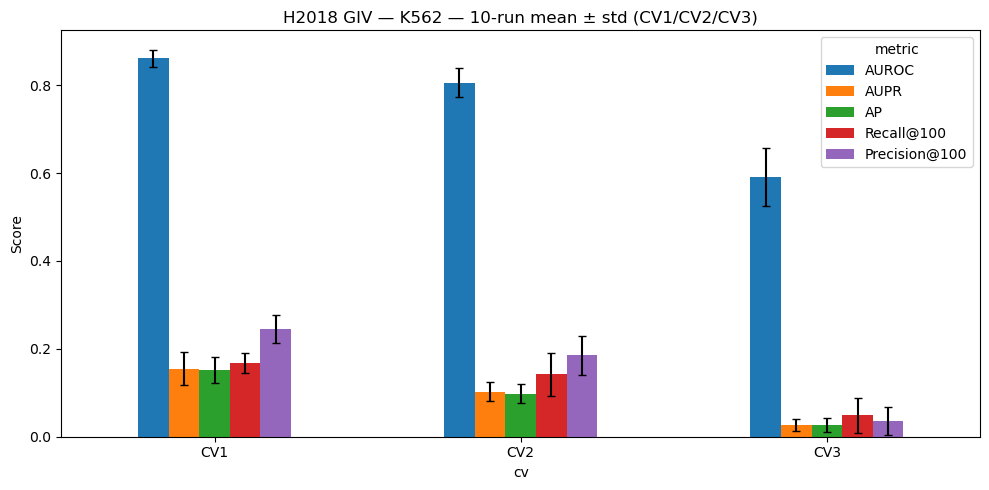

In [ ]:
# --- Quick sanity-check bar plot of CV1/CV2/CV3 averages (preview) ---
_metrics = ['AUROC', 'AUPR', 'AP', f'Recall@{TOPK}', f'Precision@{TOPK}']
_piv_mean = summary.pivot(index='cv', columns='metric', values='mean').reindex(['CV1', 'CV2', 'CV3'])[_metrics]
_piv_std  = summary.pivot(index='cv', columns='metric', values='std' ).reindex(['CV1', 'CV2', 'CV3'])[_metrics]
# Convert std -> SEM (std / sqrt(n_runs)); all CVs share the same n_runs here
_n_runs   = int(summary['n_runs'].iloc[0])
_piv_sem  = _piv_std / np.sqrt(_n_runs)

ax = _piv_mean.plot(kind='bar', yerr=_piv_sem, figsize=(10, 5), capsize=3)
ax.set_ylabel("Score")
ax.set_title(f"H2018 GIV — {CELL_LINE}562 — 10-run mean ± SEM (CV1/CV2/CV3)"
             if CELL_LINE == 'K' else
             f"H2018 GIV — Jurkat — 10-run mean ± SEM (CV1/CV2/CV3)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(REPRO_ROOT, "summary_bar_preview.pdf"), dpi=200)
plt.show()


## NCBI-description pair-embedding features — same model, same pipeline (2026-04-17)

Swap the GIV features for the pair-level NCBI-description embeddings from
`~/DeepSLP/data/input/external/H2018/Horlbeck2018_pairs_both_ncbi_descriptions_pair_embeddings.tsv`
and reuse the **exact same model architecture, loss, optimizer, and hyperparameters** defined above
(`optim_NN_pipeline` / `run_cv_repeats`). SL labels are borrowed from `df_SL_H2018_K_noNAscore` (`K_SL_n3` by default; switch `CELL_LINE` to `'J'` to use `df_SL_H2018_J_noNAscore` / `J_SL_n3`).

The embedding file has no header and uses 3 tab-separated columns: `gene1`, `gene2`, and a single comma-separated embedding string. Pairs missing from the embedding file are dropped from the modeling input.


In [9]:
# --- Load pair embeddings and build the modeling dataframe ---
EMB_PATH = "/home/b-xiangzhang/DeepSLP/data/input/external/H2018/Horlbeck2018_pairs_both_ncbi_descriptions_pair_embeddings.tsv"

# File has no header: 3 tab-separated columns (gene1, gene2, comma-separated embedding string)
df_emb_raw = pd.read_csv(EMB_PATH, sep='\t', header=None,
                         names=['gene1', 'gene2', 'embedding'])
print("Raw embedding rows:", df_emb_raw.shape)

# Expand the comma-separated embedding string into numeric columns
_emb_mat = np.stack([np.fromstring(s, sep=',', dtype=np.float32)
                     for s in df_emb_raw['embedding'].values])
EMB_DIM = _emb_mat.shape[1]
print("Embedding dim:", EMB_DIM)

emb_cols = [f'emb_{i}' for i in range(EMB_DIM)]
df_emb = pd.concat(
    [df_emb_raw[['gene1', 'gene2']].reset_index(drop=True),
     pd.DataFrame(_emb_mat, columns=emb_cols)],
    axis=1)

# Deduplicate on (gene1, gene2) just in case
before_dedup = len(df_emb)
df_emb = df_emb.drop_duplicates(subset=['gene1', 'gene2'], keep='first').reset_index(drop=True)
print(f"After dedup on (gene1,gene2): {len(df_emb)} (dropped {before_dedup - len(df_emb)})")

# Borrow SL labels and metadata from the GIV-based dataframes we built earlier
_meta_label_cols = ['gene1', 'gene2',
                    'K562 Replicate Average GI score',
                    'Jurkat Replicate Average GI score',
                    'K_SL_n3', 'J_SL_n3']

# Build K562 modeling dataframe = inner join on (gene1, gene2) with pairs that have non-NA K562 score
df_SL_H2018_K_emb = df_SL_H2018_K_noNAscore[_meta_label_cols].merge(
    df_emb, on=['gene1', 'gene2'], how='inner')
print("K562 pairs retained after merge with embeddings:",
      df_SL_H2018_K_emb.shape,
      "| pos rate:", df_SL_H2018_K_emb['K_SL_n3'].mean())

# Same for Jurkat (kept for future use)
df_SL_H2018_J_emb = df_SL_H2018_J_noNAscore[_meta_label_cols].merge(
    df_emb, on=['gene1', 'gene2'], how='inner')
print("Jurkat pairs retained after merge with embeddings:",
      df_SL_H2018_J_emb.shape,
      "| pos rate:", df_SL_H2018_J_emb['J_SL_n3'].mean())

# Non-feature cols are the same meta+label cols for both
EMB_non_feature_cols = _meta_label_cols


Raw embedding rows: (89898, 3)
Embedding dim: 1536
After dedup on (gene1,gene2): 89898 (dropped 0)
K562 pairs retained after merge with embeddings: (85903, 1542) | pos rate: 0.01687950362618302
Jurkat pairs retained after merge with embeddings: (64619, 1542) | pos rate: 0.006050851916618951


In [10]:
# --- Embedding-feature pipeline: config + choose cell line (K562 by default) ---
# Switch EMB_CELL_LINE to 'J' to train on Jurkat with the same pipeline.
EMB_CELL_LINE = 'K'   # 'K' -> K562 / K_SL_n3 ; 'J' -> Jurkat / J_SL_n3

if EMB_CELL_LINE == 'K':
    EMB_DF    = df_SL_H2018_K_emb
    EMB_LABEL = 'K_SL_n3'
    EMB_ROOT  = "/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/"
elif EMB_CELL_LINE == 'J':
    EMB_DF    = df_SL_H2018_J_emb
    EMB_LABEL = 'J_SL_n3'
    EMB_ROOT  = "/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/Jurkat/"
else:
    raise ValueError("EMB_CELL_LINE must be 'K' or 'J'")

create_directory(EMB_ROOT)
print("Embedding run — cell line:", EMB_CELL_LINE, "| label:", EMB_LABEL,
      "| #pairs:", len(EMB_DF), "| #features:", EMB_DIM,
      "| output root:", EMB_ROOT)


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/' is ready.
Embedding run — cell line: K | label: K_SL_n3 | #pairs: 85903 | #features: 1536 | output root: /home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/


In [16]:
# --- One-shot run across CV1/CV2/CV3 (single seed) ---
ONESHOT_SEED = 1843   # = 1 + SEED_BASE, matching run #1 of the 10-run sweep for consistency

oneshot_perf = {}
for _cv in (1, 2, 3):
    _ratios = CV_SPLIT[_cv]
    _out_dir = os.path.join(EMB_ROOT, f"oneshot/CV{_cv}/")
    create_directory(_out_dir)
    print(f"\n===== [Embeddings one-shot] CV{_cv} (seed={ONESHOT_SEED}) =====")
    _prefix = f"EMB_CV{_cv}_NN_h128_64_32_LR1e2_50e_p{HP['patience']}_d01_focal_oneshot"
    _model, _df_test, _perf = optim_NN_pipeline(
        df_score=EMB_DF, label_col=EMB_LABEL, non_feature_cols=EMB_non_feature_cols,
        test_ratio=_ratios['test_ratio'], val_ratio=_ratios['val_ratio'],
        rand_seed=ONESHOT_SEED,
        output_dir=_out_dir,
        plt_name=_prefix + "_ROC_PR.pdf",
        table_name=_prefix + "_preds.tsv",
        batch_size=HP['batch_size'], num_epochs=HP['num_epochs'],
        learning_rate=HP['learning_rate'], patience=HP['patience'],
        decay_factor=HP['decay_factor'],
        hidden_size1=HP['hidden_size1'], hidden_size2=HP['hidden_size2'], hidden_size3=HP['hidden_size3'],
        bool_save_model=True, model_name=_prefix + ".pth",
        scaler_direc=_prefix + "_scaler.joblib", bool_plot_loss=True,
        cv=_cv, query_col='gene1', lib_col='gene2', topk=TOPK,
        focal_alpha=HP['focal_alpha'], focal_gamma=HP['focal_gamma'])
    oneshot_perf[f"CV{_cv}"] = _perf

df_oneshot = pd.DataFrame(oneshot_perf,
                          index=['AUROC', 'AUPR', 'AP',
                                 f'Recall@{TOPK}', f'Precision@{TOPK}']).T
df_oneshot.index.name = 'cv'
df_oneshot.to_csv(os.path.join(EMB_ROOT, "oneshot/oneshot_performance.tsv"), sep='\t')
print("\n=== Embeddings one-shot performance ===")
df_oneshot


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/oneshot/CV1/' is ready.

===== [Embeddings one-shot] CV1 (seed=1843) =====
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/oneshot/CV1/' is ready.
Data split: CV1 | seed=1843
Train=68391, Val=8549, Test=8549
Using cuda device
[2026-04-17 16:56:29] Training started
Ep 1/50: TrL=0.0252 VaL=0.0203 | TrAUPR=0.1057 VaAUPR=0.1309
Ep 2/50: TrL=0.0214 VaL=0.0205 | TrAUPR=0.1044 VaAUPR=0.1016
Ep 3/50: TrL=0.0203 VaL=0.0204 | TrAUPR=0.1166 VaAUPR=0.1263
Ep 4/50: TrL=0.0200 VaL=0.0195 | TrAUPR=0.1435 VaAUPR=0.1366
Ep 5/50: TrL=0.0193 VaL=0.0196 | TrAUPR=0.1505 VaAUPR=0.1540
Ep 6/50: TrL=0.0190 VaL=0.0196 | TrAUPR=0.1716 VaAUPR=0.1538
Ep 7/50: TrL=0.0187 VaL=0.0189 | TrAUPR=0.1790 VaAUPR=0.1487
Ep 8/50: TrL=0.0183 VaL=0.0193 | TrAUPR=0.1978 VaAUPR=0.1484
Ep 9/50: TrL=0.0177 VaL=0.0200 | TrAUPR=0.2009 VaAUPR=0.1531
Ep 10/50: TrL=0.0178 VaL=0.0187 | TrAUPR=0.2099 VaAUPR=0.1539
Ep 11/50: TrL=0.01

,AUROC,AUPR,AP,Recall@100,Precision@100
cv,,,,,
CV1,0.880689,0.190282,0.195371,0.244275,0.32
CV2,0.779756,0.100073,0.079029,0.145038,0.19
CV3,0.439893,0.011217,0.011633,0.000000,0.00


In [11]:
# --- 10 random-seed runs for CV1/CV2/CV3 (reuses run_cv_repeats from above) ---
EMB_REPEAT_ROOT = os.path.join(EMB_ROOT, "repeats/")
create_directory(EMB_REPEAT_ROOT)

df_emb_perf_cv1 = run_cv_repeats(
    cv=1, df_score=EMB_DF, label_col=EMB_LABEL, non_feature_cols=EMB_non_feature_cols,
    output_root=EMB_REPEAT_ROOT, n_runs=N_RUNS, seed_base=SEED_BASE, topk=TOPK,
    query_col='gene1', lib_col='gene2', prefix_tag="EMB_CV1")

# Need to change seed for cv2/3 for batch size issue
df_emb_perf_cv2 = run_cv_repeats(
    cv=2, df_score=EMB_DF, label_col=EMB_LABEL, non_feature_cols=EMB_non_feature_cols,
    output_root=EMB_REPEAT_ROOT, n_runs=N_RUNS, seed_base=SEED_BASE, topk=TOPK,
    query_col='gene1', lib_col='gene2', prefix_tag="EMB_CV2")

df_emb_perf_cv3 = run_cv_repeats(
    cv=3, df_score=EMB_DF, label_col=EMB_LABEL, non_feature_cols=EMB_non_feature_cols,
    output_root=EMB_REPEAT_ROOT, n_runs=N_RUNS, seed_base=SEED_BASE, topk=TOPK,
    query_col='gene1', lib_col='gene2', prefix_tag="EMB_CV3")


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/repeats/' is ready.
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/repeats/CV1/' is ready.

===== EMB_CV1 run 1/10 (seed=1843) =====
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/repeats/CV1/' is ready.
Data split: CV1 | seed=1843
Train=68391, Val=8549, Test=8549
Using cuda device
[2026-04-18 23:01:37] Training started
Ep 1/50: TrL=0.0250 VaL=0.0213 | TrAUPR=0.0882 VaAUPR=0.0803
Ep 2/50: TrL=0.0213 VaL=0.0203 | TrAUPR=0.1166 VaAUPR=0.1019
Ep 3/50: TrL=0.0205 VaL=0.0205 | TrAUPR=0.1170 VaAUPR=0.0934
Ep 4/50: TrL=0.0200 VaL=0.0198 | TrAUPR=0.1349 VaAUPR=0.1190
Ep 5/50: TrL=0.0195 VaL=0.0202 | TrAUPR=0.1453 VaAUPR=0.1447
Ep 6/50: TrL=0.0192 VaL=0.0200 | TrAUPR=0.1483 VaAUPR=0.1291
Ep 7/50: TrL=0.0190 VaL=0.0206 | TrAUPR=0.1312 VaAUPR=0.0943
Ep 8/50: TrL=0.0183 VaL=0.0202 | TrAUPR=0.1690 VaAUPR=0.1537
Ep 9/50: TrL=0.0179 VaL=0.0195 | TrAUPR=0.1677 VaAUPR

ValueError: Target size (torch.Size([1])) must be the same as input size (torch.Size([]))

In [15]:
# Change seed for cv2 due to batch size issue
df_emb_perf_cv2 = run_cv_repeats(
    cv=2, df_score=EMB_DF, label_col=EMB_LABEL, non_feature_cols=EMB_non_feature_cols,
    output_root=EMB_REPEAT_ROOT, n_runs=N_RUNS, seed_base=1897, topk=TOPK,
    query_col='gene1', lib_col='gene2', prefix_tag="EMB_CV2")


Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/repeats/CV2/' is ready.

===== EMB_CV2 run 1/10 (seed=1898) =====
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/repeats/CV2/' is ready.
Data split: CV2 | seed=1898
413 unique queries
331 train / 41 val / 41 test queries
Shapes: (68136, 1536) (8387, 1536) (8966, 1536)
Using cuda device
[2026-04-19 00:06:26] Training started
Ep 1/50: TrL=0.0267 VaL=0.0199 | TrAUPR=0.0970 VaAUPR=0.0317
Ep 2/50: TrL=0.0216 VaL=0.0188 | TrAUPR=0.1287 VaAUPR=0.0374
Ep 3/50: TrL=0.0204 VaL=0.0187 | TrAUPR=0.1323 VaAUPR=0.0377
Ep 4/50: TrL=0.0199 VaL=0.0186 | TrAUPR=0.1539 VaAUPR=0.0382
Ep 5/50: TrL=0.0198 VaL=0.0185 | TrAUPR=0.0952 VaAUPR=0.0370
Ep 6/50: TrL=0.0193 VaL=0.0188 | TrAUPR=0.1485 VaAUPR=0.0503
Ep 7/50: TrL=0.0189 VaL=0.0186 | TrAUPR=0.1783 VaAUPR=0.0454
Ep 8/50: TrL=0.0186 VaL=0.0210 | TrAUPR=0.1590 VaAUPR=0.0393
Ep 9/50: TrL=0.0183 VaL=0.0197 | TrAUPR=0.1672 VaAUPR=0.0360
Ep 10/50: TrL=0.01

In [16]:

df_emb_perf_cv3 = run_cv_repeats(
    cv=3, df_score=EMB_DF, label_col=EMB_LABEL, non_feature_cols=EMB_non_feature_cols,
    output_root=EMB_REPEAT_ROOT, n_runs=N_RUNS, seed_base=SEED_BASE, topk=TOPK,
    query_col='gene1', lib_col='gene2', prefix_tag="EMB_CV3")

Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/repeats/CV3/' is ready.

===== EMB_CV3 run 1/10 (seed=1843) =====
Directory '/home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/repeats/CV3/' is ready.
Data split: CV3 | seed=1843
Shapes: (28440, 1536) (3741, 1536) (3740, 1536)
Excluded pairs: 49568
Using cuda device
[2026-04-19 00:36:39] Training started
Ep 1/50: TrL=0.0286 VaL=0.0217 | TrAUPR=0.0876 VaAUPR=0.0436
Ep 2/50: TrL=0.0230 VaL=0.0233 | TrAUPR=0.1332 VaAUPR=0.0269
Ep 3/50: TrL=0.0218 VaL=0.0248 | TrAUPR=0.1578 VaAUPR=0.0235
Ep 4/50: TrL=0.0211 VaL=0.0257 | TrAUPR=0.1510 VaAUPR=0.0268
Ep 5/50: TrL=0.0204 VaL=0.0272 | TrAUPR=0.1733 VaAUPR=0.0319
Ep 6/50: TrL=0.0200 VaL=0.0280 | TrAUPR=0.1886 VaAUPR=0.0343
Ep 7/50: TrL=0.0196 VaL=0.0244 | TrAUPR=0.2097 VaAUPR=0.0340
Ep 8/50: TrL=0.0176 VaL=0.0280 | TrAUPR=0.2406 VaAUPR=0.0319
Ep 9/50: TrL=0.0169 VaL=0.0301 | TrAUPR=0.2630 VaAUPR=0.0309
Ep 10/50: TrL=0.0167 VaL=0.0333 | TrAUPR=0.2809 VaAU

In [20]:
# --- Aggregate embedding-feature 10-run performance across CV1/CV2/CV3 ---
emb_summary = pd.concat([
    _summarize(df_emb_perf_cv1, 'CV1'),
    _summarize(df_emb_perf_cv2, 'CV2'),
    _summarize(df_emb_perf_cv3, 'CV3'),
], ignore_index=True)
emb_summary_path = os.path.join(EMB_ROOT, "summary_mean_std.tsv")
emb_summary.to_csv(emb_summary_path, sep='\t', index=False)
print("Wrote:", emb_summary_path)
emb_summary


Wrote: /home/b-xiangzhang/DeepSLP/outputs/H2018_embeddings_04172026/K562/summary_mean_std.tsv


,metric,mean,std,cv,n_runs
0,AUROC,0.854421,0.017502,CV1,10
1,AUPR,0.148833,0.017829,CV1,10
2,AP,0.148400,0.024460,CV1,10
3,Recall@100,0.174809,0.026309,CV1,10
4,Precision@100,0.229000,0.034464,CV1,10
5,AUROC,0.800571,0.027064,CV2,10
6,AUPR,0.101271,0.036152,CV2,10
7,AP,0.086854,0.028112,CV2,10
8,Recall@100,0.117395,0.032190,CV2,10
9,Precision@100,0.154000,0.056999,CV2,10


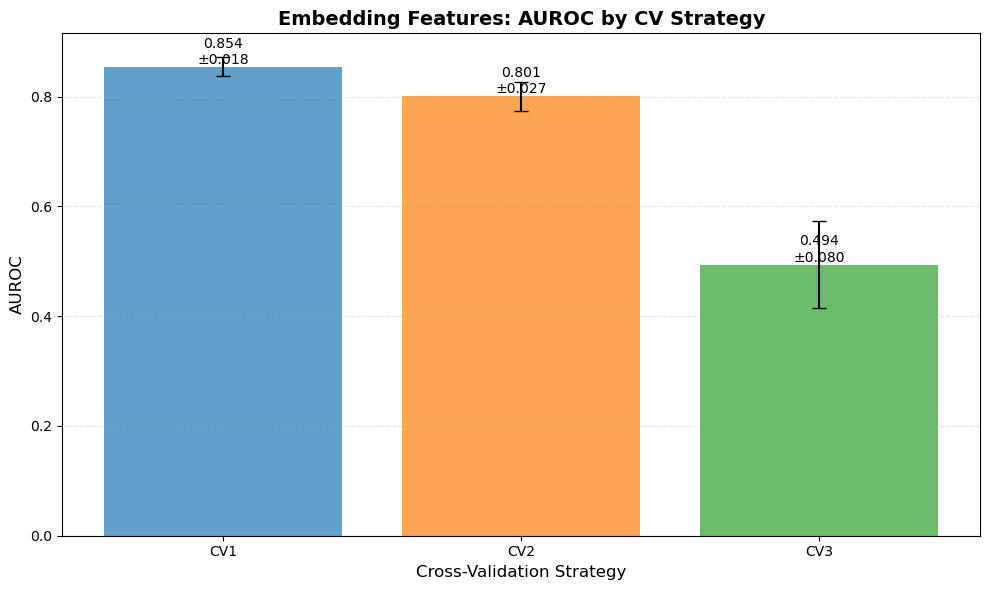

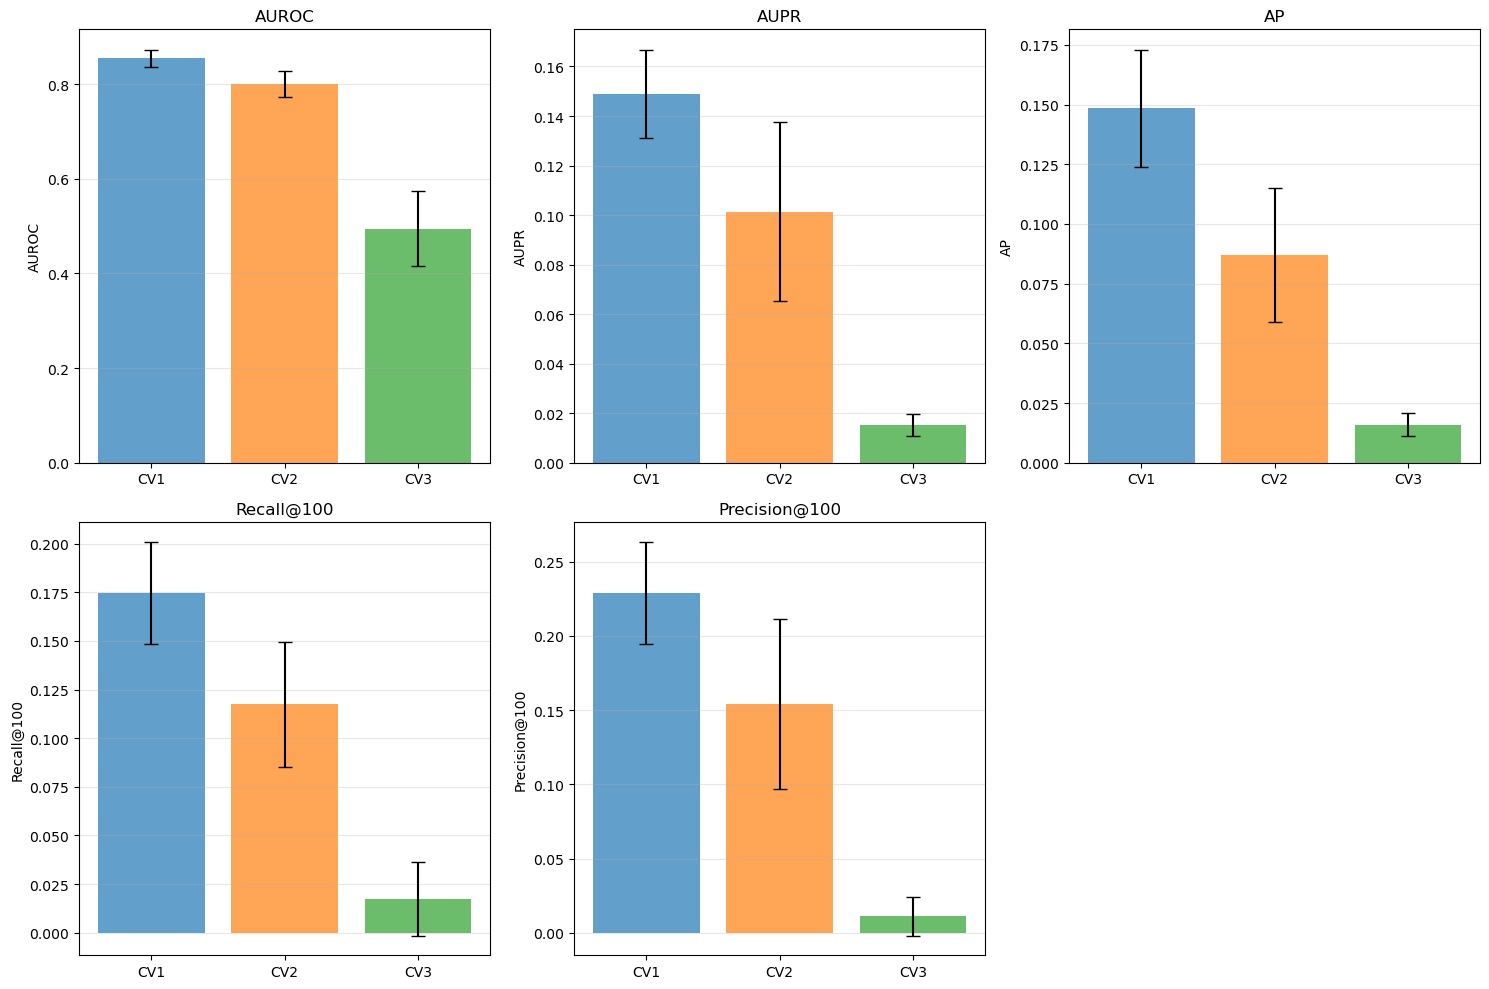

In [ ]:
def plot_performance_by_cv(summary_df, metric='AUROC', figsize=(10, 6), title=None):
    """
    Create a bar plot of performance metrics by CV type with error bars.

    Parameters:
    -----------
    summary_df : pd.DataFrame
        Summary dataframe with columns: 'metric', 'mean', 'std', 'cv', 'n_runs'
    metric : str, default='AUROC'
        The metric to plot (must be in summary_df['metric'])
    figsize : tuple, default=(10, 6)
        Figure size as (width, height)
    title : str, optional
        Plot title. If None, defaults to f"{metric} by CV"

    Returns:
    --------
    ax : matplotlib.axes.Axes
        The axes object containing the plot

    Notes
    -----
    Error bars are SEM = std / sqrt(n_runs).
    """
    # Filter data for the specified metric
    df_metric = summary_df[summary_df['metric'] == metric].copy()

    if df_metric.empty:
        raise ValueError(f"Metric '{metric}' not found in summary_df")

    # Sort by CV for consistent ordering
    cv_order = ['CV1', 'CV2', 'CV3']
    df_metric['cv'] = pd.Categorical(df_metric['cv'], categories=cv_order, ordered=True)
    df_metric = df_metric.sort_values('cv')

    # Compute SEM from std and n_runs
    df_metric['sem'] = df_metric['std'] / np.sqrt(df_metric['n_runs'])

    # Create bar plot
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(df_metric['cv'], df_metric['mean'],
                   yerr=df_metric['sem'], capsize=5, alpha=0.7,
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])

    # Customize plot
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel('Cross-Validation Strategy', fontsize=12)
    ax.set_title(title or f"{metric} by CV (mean ± SEM)", fontsize=14, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for i, (bar, row) in enumerate(zip(bars, df_metric.itertuples())):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}\n±{row.sem:.3f}',
                ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    return ax


# Usage example:
ax = plot_performance_by_cv(emb_summary, metric='AUROC',
                             title='Embedding Features: AUROC by CV Strategy (mean ± SEM)')
plt.savefig(os.path.join(EMB_ROOT, 'performance_by_cv_auroc.pdf'), dpi=200)
plt.show()

# Plot multiple metrics in a grid
metrics_to_plot = ['AUROC', 'AUPR', 'AP', 'Recall@100', 'Precision@100']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    df_m = emb_summary[emb_summary['metric'] == metric].copy()
    df_m = df_m.sort_values('cv')
    df_m['sem'] = df_m['std'] / np.sqrt(df_m['n_runs'])
    ax.bar(df_m['cv'], df_m['mean'], yerr=df_m['sem'], capsize=5,
           alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} (mean ± SEM)")
    ax.grid(axis='y', alpha=0.3)

# Hide the last empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(EMB_ROOT, 'performance_all_metrics_grid.pdf'), dpi=200)
plt.show()


In [ ]:
# Compare DepMap GIV features and LLM embedding features side by side


## Compare GIV vs LLM-embedding features across CV1/CV2/CV3 (mean ± SEM)

Load the `*_performance_stats_10runs.tsv` files written by the `run_cv_repeats(...)` sweeps and plot a grouped bar chart: three CV groups × two feature sources (GIV vs LLM).


In [19]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Roots for the two feature sources. Cell line subfolder is configurable.
H2018_OUTPUTS_ROOT = "/home/b-xiangzhang/DeepSLP/outputs"
FEATURE_ROOTS = {
    'GIV': os.path.join(H2018_OUTPUTS_ROOT, "H2018_reproduce_04172026"),
    'LLM': os.path.join(H2018_OUTPUTS_ROOT, "H2018_embeddings_04172026"),
}

STATS_GLOB = "*performance_stats_10runs.tsv"
CV_LIST = ['CV1', 'CV2', 'CV3']


def _find_stats_file(feature_root, cell_line, cv):
    """Locate the *_performance_stats_10runs.tsv under a CV folder.

    Tries both layouts we've written:
      {feature_root}/{cell_line}/{cv}/*performance_stats_10runs.tsv
      {feature_root}/{cell_line}/repeats/{cv}/*performance_stats_10runs.tsv
    """
    candidates = [
        os.path.join(feature_root, cell_line, cv, STATS_GLOB),
        os.path.join(feature_root, cell_line, "repeats", cv, STATS_GLOB),
    ]
    for pat in candidates:
        matches = sorted(glob.glob(pat))
        if matches:
            if len(matches) > 1:
                print(f"[warn] multiple stats files for {cv} under {pat}; using the newest")
                matches.sort(key=os.path.getmtime)
            return matches[-1]
    raise FileNotFoundError(
        f"No stats file found for {cv} under any of: {candidates}")


def load_perf_stats(feature_roots=FEATURE_ROOTS, cell_line='K562', cv_list=CV_LIST):
    """Return a long-form dataframe: columns = feature, cv, seed, metric, value."""
    rows = []
    for feat_name, feat_root in feature_roots.items():
        for cv in cv_list:
            path = _find_stats_file(feat_root, cell_line, cv)
            df = pd.read_csv(path, sep='\t')
            metric_cols = [c for c in df.columns if c != 'seed']
            long = df.melt(id_vars=[c for c in ['seed'] if c in df.columns],
                           value_vars=metric_cols,
                           var_name='metric', value_name='value')
            long['feature'] = feat_name
            long['cv'] = cv
            long['source_file'] = path
            rows.append(long)
            print(f"[{feat_name}][{cv}] n_runs={len(df)} | {os.path.relpath(path, H2018_OUTPUTS_ROOT)}")
    return pd.concat(rows, ignore_index=True)


df_perf_long = load_perf_stats(cell_line='K562')
print("\nAvailable metrics:", sorted(df_perf_long['metric'].unique()))
df_perf_long.head()


[GIV][CV1] n_runs=10 | H2018_reproduce_04172026/K562/CV1/CV1_GIV_NN_h128_64_32_LR1e2_50e_p10_d01_focal_performance_stats_10runs.tsv
[GIV][CV2] n_runs=10 | H2018_reproduce_04172026/K562/CV2/CV2_GIV_NN_h128_64_32_LR1e2_50e_p10_d01_focal_performance_stats_10runs.tsv
[GIV][CV3] n_runs=10 | H2018_reproduce_04172026/K562/CV3/CV3_GIV_NN_h128_64_32_LR1e2_50e_p10_d01_focal_performance_stats_10runs.tsv
[LLM][CV1] n_runs=10 | H2018_embeddings_04172026/K562/repeats/CV1/EMB_CV1_GIV_NN_h128_64_32_LR1e2_50e_p10_d01_focal_performance_stats_10runs.tsv
[LLM][CV2] n_runs=10 | H2018_embeddings_04172026/K562/repeats/CV2/EMB_CV2_GIV_NN_h128_64_32_LR1e2_50e_p10_d01_focal_performance_stats_10runs.tsv
[LLM][CV3] n_runs=10 | H2018_embeddings_04172026/K562/repeats/CV3/EMB_CV3_GIV_NN_h128_64_32_LR1e2_50e_p10_d01_focal_performance_stats_10runs.tsv

Available metrics: ['AP', 'AUPR', 'AUROC', 'Precision@100', 'Recall@100']


,seed,metric,value,feature,cv,source_file
0,1843,AUROC,0.860668,GIV,CV1,/home/b-xiangzhang/DeepSLP/outputs/H2018_repro...
1,1844,AUROC,0.877599,GIV,CV1,/home/b-xiangzhang/DeepSLP/outputs/H2018_repro...
2,1845,AUROC,0.849768,GIV,CV1,/home/b-xiangzhang/DeepSLP/outputs/H2018_repro...
3,1846,AUROC,0.849493,GIV,CV1,/home/b-xiangzhang/DeepSLP/outputs/H2018_repro...
4,1847,AUROC,0.827227,GIV,CV1,/home/b-xiangzhang/DeepSLP/outputs/H2018_repro...


In [20]:
def plot_metric_bar(df_long, metric,
                    cv_list=CV_LIST, feature_order=('GIV', 'LLM'),
                    colors=('#4C72B0', '#DD8452'),
                    bar_width=0.35, figsize=(7, 4.5),
                    show_points=True, save_path=None, ax=None):
    """Grouped bar plot for one metric: 3 CV groups × 2 feature sources.

    Heights are per-run mean; error bars are SEM (std / sqrt(n_runs)).
    `df_long` comes from `load_perf_stats(...)`.
    """
    sub = df_long[df_long['metric'] == metric]
    if sub.empty:
        raise ValueError(f"metric '{metric}' not found. Available: {sorted(df_long['metric'].unique())}")

    stats = (sub.groupby(['feature', 'cv'])['value']
               .agg(['mean', 'std', 'count'])
               .reset_index())
    stats['sem'] = stats['std'] / np.sqrt(stats['count'])

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    x = np.arange(len(cv_list))
    offsets = np.linspace(-(len(feature_order) - 1) / 2,
                           (len(feature_order) - 1) / 2,
                           len(feature_order)) * bar_width

    for i, feat in enumerate(feature_order):
        means = [stats.query("feature == @feat and cv == @cv")['mean'].values[0]
                 if not stats.query("feature == @feat and cv == @cv").empty else np.nan
                 for cv in cv_list]
        sems  = [stats.query("feature == @feat and cv == @cv")['sem'].values[0]
                 if not stats.query("feature == @feat and cv == @cv").empty else np.nan
                 for cv in cv_list]
        ax.bar(x + offsets[i], means, width=bar_width, yerr=sems, capsize=4,
               label=feat, color=colors[i % len(colors)], edgecolor='black', linewidth=0.6)

        if show_points:
            for j, cv in enumerate(cv_list):
                pts = sub.query("feature == @feat and cv == @cv")['value'].values
                if len(pts) == 0:
                    continue
                jitter = (np.random.RandomState(0).uniform(-0.06, 0.06, size=len(pts)))
                ax.scatter(np.full_like(pts, x[j] + offsets[i], dtype=float) + jitter,
                           pts, s=14, color='black', alpha=0.55, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(cv_list)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} — GIV vs LLM embeddings (mean ± SEM over 10 runs)")
    ax.legend(title='Features', frameon=False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    fig.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print("Saved:", save_path)

    return fig, ax, stats


Saved: /home/b-xiangzhang/DeepSLP/outputs/H2018_GIV_vs_LLM_comparison_04202026/K562_AUROC_bar.pdf


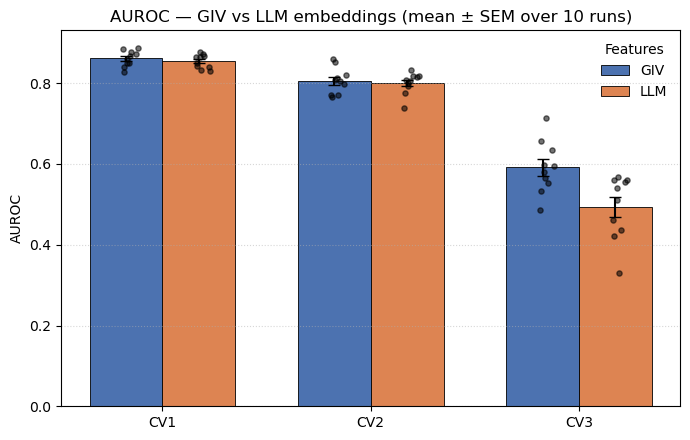

,feature,cv,mean,std,count,sem
0,GIV,CV1,0.861502,0.019504,10,0.006168
1,GIV,CV2,0.806077,0.032612,10,0.010313
2,GIV,CV3,0.591271,0.065242,10,0.020631
3,LLM,CV1,0.854421,0.017502,10,0.005535
4,LLM,CV2,0.800571,0.027064,10,0.008558
5,LLM,CV3,0.494246,0.079548,10,0.025155


In [21]:
# Example: plot one metric at a time (change `metric` to any of the available ones)
COMPARE_PLOT_DIR = os.path.join(H2018_OUTPUTS_ROOT, "H2018_GIV_vs_LLM_comparison_04202026")

metric = 'AUROC'
fig, ax, stats = plot_metric_bar(
    df_perf_long, metric=metric,
    save_path=os.path.join(COMPARE_PLOT_DIR, f"K562_{metric}_bar.pdf"))
plt.show()
stats


Saved: /home/b-xiangzhang/DeepSLP/outputs/H2018_GIV_vs_LLM_comparison_04202026/K562_Precision@100_bar.pdf


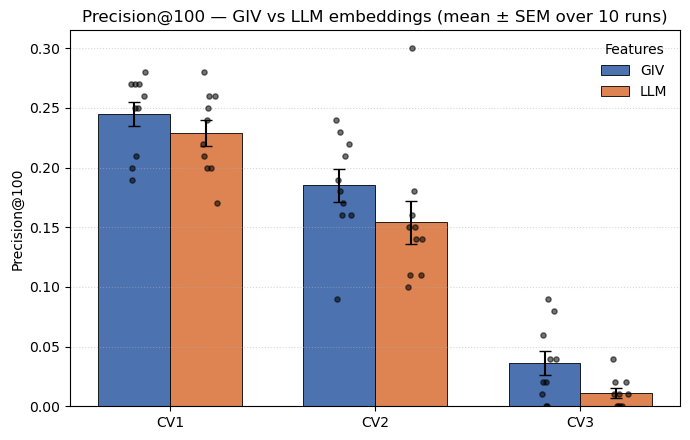

,feature,cv,mean,std,count,sem
0,GIV,CV1,0.245,0.032745,10,0.010355
1,GIV,CV2,0.185,0.044033,10,0.013924
2,GIV,CV3,0.036,0.032042,10,0.010132
3,LLM,CV1,0.229,0.034464,10,0.010899
4,LLM,CV2,0.154,0.056999,10,0.018025
5,LLM,CV3,0.011,0.012867,10,0.004069


In [24]:
# Example: plot one metric at a time (change `metric` to any of the available ones)
COMPARE_PLOT_DIR = os.path.join(H2018_OUTPUTS_ROOT, "H2018_GIV_vs_LLM_comparison_04202026")

metric = 'Precision@100'
fig, ax, stats = plot_metric_bar(
    df_perf_long, metric=metric,
    save_path=os.path.join(COMPARE_PLOT_DIR, f"K562_{metric}_bar.pdf"))
plt.show()
stats


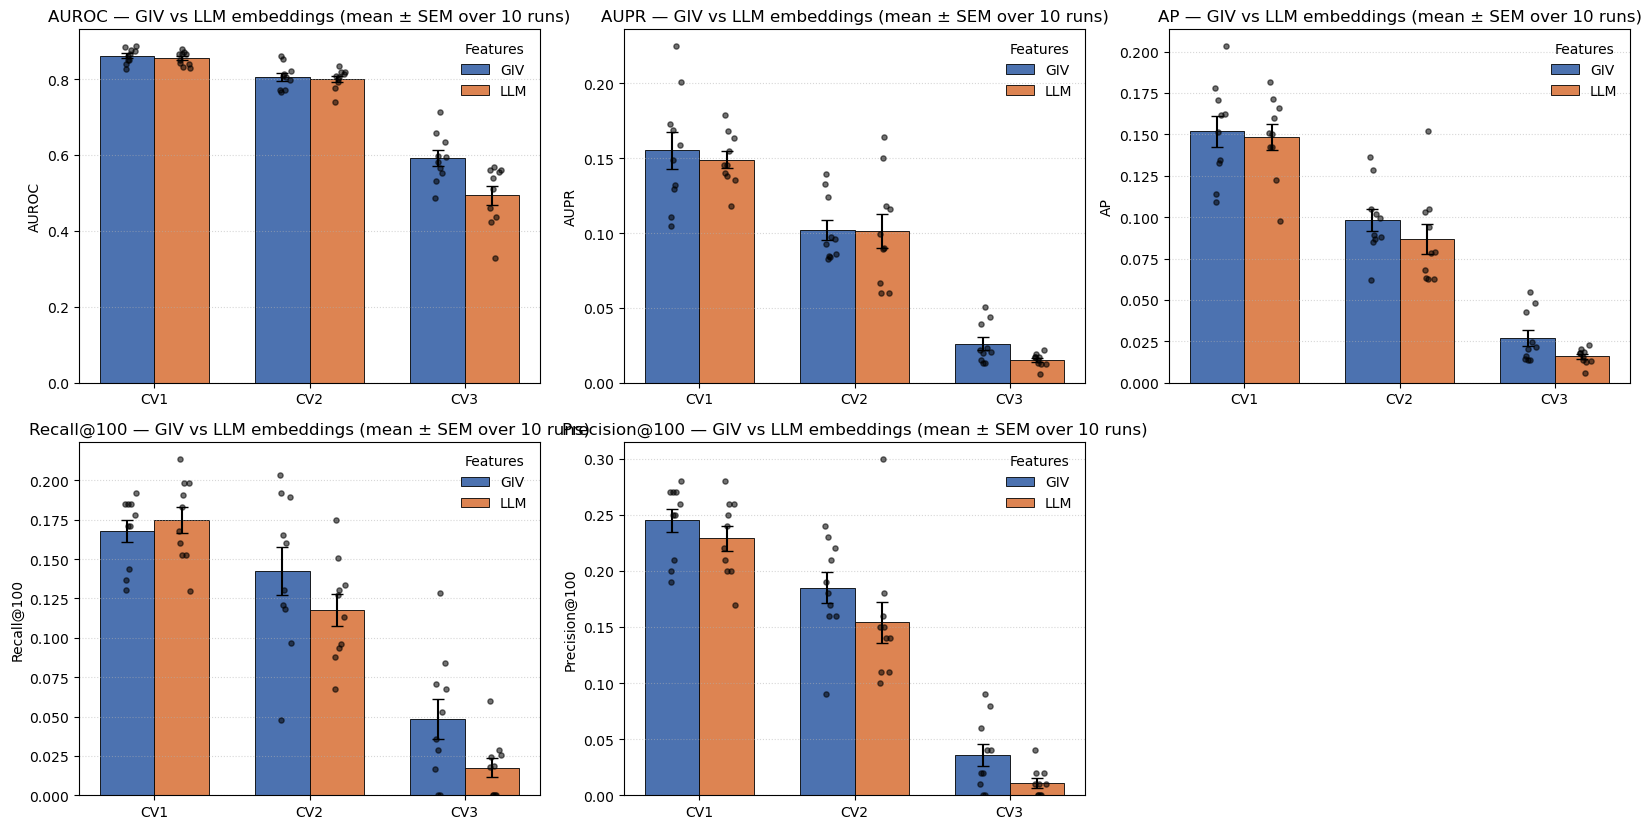

In [23]:
# Convenience: render one plot per metric in a grid (all metrics at once)
all_metrics = sorted(df_perf_long['metric'].unique(),
                     key=lambda m: ['AUROC', 'AUPR', 'AP'].index(m) if m in ['AUROC', 'AUPR', 'AP'] else 99)
ncols = 3
nrows = int(np.ceil(len(all_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.2 * nrows))
axes = np.atleast_2d(axes).ravel()
for i, m in enumerate(all_metrics):
    plot_metric_bar(df_perf_long, metric=m, ax=axes[i], show_points=True)
for j in range(len(all_metrics), len(axes)):
    axes[j].axis('off')
fig.tight_layout()
fig.savefig(os.path.join(COMPARE_PLOT_DIR, "K562_all_metrics_grid.pdf"),
            dpi=300, bbox_inches='tight')
plt.show()
